In [ ]:
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import warnings
warnings.filterwarnings('ignore')

# Add utils to path
sys.path.append("/mnt/cbib/LNClassifier/paper/workflow/")
from utils.features import filter_feature_columns, custom_feature_scaling, get_probabilities
from utils.parsing import load_tables, simple_load_ids
from utils.entropy import load_dataset
import utils.plotting

In [ ]:
DATASET = "gencode.v47.common.cdhit.cv"
BASEDIR = Path("/mnt/cbib/LNClassifier/paper/")

LOW_TH = 25
HIGH_TH = 75

In [ ]:
# Load tables using the parsing utility
dataset = load_dataset(DATASET)
features_df = filter_feature_columns(dataset["features"])
labels = dataset["labels"]
probs = dataset["probs"]
entropy_file = f"results/{DATASET}/features/entropy/{DATASET}_uncertainty_analysis.tsv"
entropy_df = pd.read_csv(BASEDIR / entropy_file, sep="\t", index_col=0)

Extracted 8 probability columns.
Inverting noncoding probabilities...
  - Inverting column: Noncoding_prob_ss_lncDC
Identified length columns to exclude: ['Transcript_length_lncDC', 'length_plncpro'] (keeping RNA_size_feelnc for reference)
Total number of columns in features table: 172
Number of kept feature columns: 128
Feature columns: ['kmerScore_1mer_feelnc', 'kmerScore_2mer_feelnc', 'kmerScore_3mer_feelnc', 'kmerScore_6mer_feelnc', 'kmerScore_9mer_feelnc', 'kmerScore_12mer_feelnc', 'ORF_cover_feelnc', 'RNA_size_feelnc', 'ORF_l_cpat', 'Fickett_l_cpat', 'Hexamer_l_cpat', 'ORF_coverage_l_cpat', 'GC_content_lncDC', 'Fickett_score_lncDC', 'ORF_T0_length_lncDC', 'ORF_T1_length_lncDC', 'ORF_T2_length_lncDC', 'ORF_T0_coverage_lncDC', 'ORF_T1_coverage_lncDC', 'ORF_T3_coverage_lncDC', 'Hexamer_score_ORF_T0_lncDC', 'Hexamer_score_ORF_T1_lncDC', 'Hexamer_score_ORF_T2_lncDC', 'Hexamer_score_ORF_T3_lncDC', 'RCB_T0_lncDC', 'RCB_T1_lncDC', 'ORF_T0_PI_lncDC', 'ORF_T0_MW_lncDC', 'ORF_T0_aromaticity

In [ ]:
probs

,coding_score_rnasamba,coding_potential_feelnc,Coding_prob_l_cpat,Noncoding_prob_ss_lncDC,coding_prob_mrnn,P(pcRNA)_lncrnabert,prob_coding_plncpro,Coding.Potential_ss_lncfinder
seq_ID,,,,,,,,
ENST00000000412.8,0.99411,0.958,0.933894,0.999833,0.978755,0.999992,0.956,0.989447
ENST00000002596.6,0.98732,0.954,0.996628,0.996186,0.910619,0.999992,0.585,0.995086
ENST00000002829.8,0.99930,1.000,0.998778,0.998462,0.986240,0.999993,0.998,0.970563
ENST00000005260.9,0.99168,0.980,0.980331,0.999546,0.978858,0.999992,0.995,0.959779
ENST00000005995.8,0.97452,0.994,0.942528,0.999394,0.990389,0.999991,0.979,0.891659
...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.04422,0.010,0.171249,0.000282,0.353438,0.000003,0.044,0.059889
ENST00000715718.1,0.00632,0.022,0.289002,0.000984,0.022870,0.000002,0.026,0.112075
ENST00000715720.1,0.24308,0.016,0.172799,0.004180,0.113424,0.000003,0.083,0.049054


In [ ]:
entropy_df

,coding_score_rnasamba_entropy,coding_potential_feelnc_entropy,Coding_prob_l_cpat_entropy,Noncoding_prob_ss_lncDC_entropy,coding_prob_mrnn_entropy,P(pcRNA)_lncrnabert_entropy,prob_coding_plncpro_entropy,Coding.Potential_ss_lncfinder_entropy,H_exp,H_pred,I_bald,coding_class,biotype
seq_ID,,,,,,,,,,,,,
ENST00000000412.8,0.052103,0.251388,0.351220,0.002338,0.148375,0.000145,0.260341,0.084436,0.143793,0.161986,0.018193,1,coding
ENST00000002596.6,0.098077,0.269156,0.032545,0.036134,0.434400,0.000143,0.979051,0.044755,0.236783,0.372960,0.136177,1,coding
ENST00000002829.8,0.008346,0.000000,0.013588,0.016586,0.104798,0.000133,0.020814,0.191563,0.044478,0.053527,0.009048,1,coding
ENST00000005260.9,0.069438,0.141441,0.139579,0.005691,0.147805,0.000155,0.045415,0.243306,0.099104,0.108427,0.009323,1,coding
ENST00000005995.8,0.171191,0.052915,0.317326,0.007353,0.078203,0.000157,0.147019,0.494893,0.158632,0.187143,0.028511,1,coding
...,...,...,...,...,...,...,...,...,...,...,...,...,...
ENST00000715715.1,0.261317,0.080793,0.660554,0.003736,0.937101,0.000055,0.260341,0.327004,0.316363,0.420876,0.104513,0,lncRNA
ENST00000715718.1,0.055262,0.152527,0.867429,0.011245,0.157265,0.000043,0.173917,0.506143,0.240479,0.327074,0.086595,0,lncRNA
ENST00000715720.1,0.800125,0.118350,0.664067,0.039050,0.510158,0.000054,0.412663,0.282365,0.353354,0.420216,0.066862,0,lncRNA


In [ ]:
low_th = np.percentile(entropy_df["H_pred"], LOW_TH)
high_th_pred = np.percentile(entropy_df["H_pred"], HIGH_TH)
high_th_bald = np.percentile(entropy_df["I_bald"], HIGH_TH)

entropy_df["entropy_class"] = 'other'

entropy_df.loc[entropy_df["H_pred"] < low_th, "entropy_class"] = "low"
entropy_df.loc[(entropy_df["H_pred"] > high_th_pred) & (entropy_df["I_bald"] > high_th_bald), "entropy_class"] = "high"

In [ ]:
def plot_uncertainty_scatter(df, entropy_col='H_pred', bald_col='I_bald', 
                            color_by=None, title=None, figsize=(10, 8),
                            **kwargs):
    """
    Create scatter plot of H_pred vs I_bald with optional coloring.
    
    Parameters:
    -----------
    df : pd.DataFrame
        DataFrame with uncertainty metrics
    entropy_col : str
        Column for x-axis (predictive entropy)
    bald_col : str
        Column for y-axis (BALD)
    color_by : str
        Column to use for coloring points
    title : str, optional
        Plot title
    figsize : tuple
        Figure size
    """

    dpi = kwargs.get('dpi', 100)
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
    
    if color_by and color_by in df.columns:
        for category in df[color_by].unique():
            mask = df[color_by] == category
            ax.scatter(df.loc[mask, entropy_col], 
                      df.loc[mask, bald_col],
                      label=category, colorsalpha=0.6, s=1)
        ax.legend()
    else:
        ax.scatter(df[entropy_col], df[bald_col], alpha=0.6, s=5)
    
    ax.set_xlabel(f'{entropy_col} (Predictive Entropy)', fontweight='bold')
    ax.set_ylabel(f'{bald_col} (BALD)', fontweight='bold')
    ax.set_title(title or 'Uncertainty Space', fontweight='bold', fontsize=14)
    plt.tight_layout()
    return fig

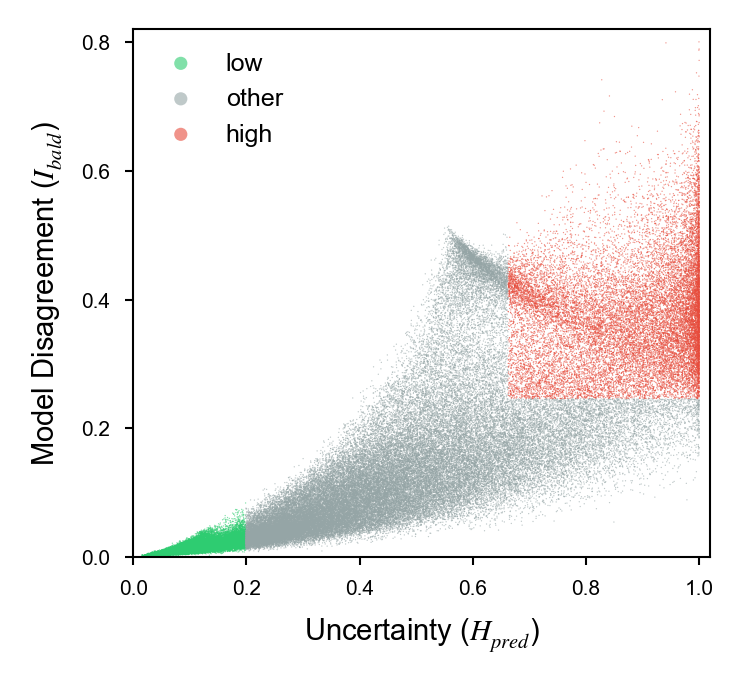

Thresholds used for binning:
------------------------------
Low percentile: 25
High percentile: 75
Low H_pred threshold: 0.1987
High H_pred threshold: 0.6624
High I_bald threshold: 0.2461


In [ ]:
fig_w_cm = 6
fig_h_cm = 5.5
figsize = (fig_w_cm / 2.54, fig_h_cm / 2.54)  # Convert cm to inches
dpi = 300

fig, ax = plt.subplots(figsize=figsize, dpi=dpi)
df = entropy_df.copy()
entropy_col = "H_pred"
bald_col = "I_bald"
color_by = "entropy_class"

for category in df[color_by].unique():
    mask = df[color_by] == category
    ax.scatter(df.loc[mask, entropy_col], 
               df.loc[mask, bald_col],
               marker='o',
               facecolors=utils.plotting.COLORS["entropy_class"][category],
               edgecolors='none',
               linewidths=0,
               label=category, alpha=0.6, s=0.1)

# # plot threshold lines
# ax.axvline(low_th, color='gray', linestyle='--', linewidth=0.8, label=f'Low H_pred ({low_th:.2f})', zorder=0)
# ax.axvline(high_th_pred, color='black', linestyle='--', linewidth=0.8, label=f'High H_pred ({high_th_pred:.2f})', zorder=0)
# ax.axhline(high_th_bald, color='black', linestyle=':', linewidth=0.8, label=f'High I_bald ({high_th_bald:.2f})', zorder=0)

ax.legend(markerscale=10, frameon=False)


# X-axis
# optional: make math letters upright by default
plt.rcParams['mathtext.default'] = 'regular'
plt.rcParams['mathtext.fontset'] = 'stix'
ax.set_xlabel(r'Uncertainty ($\mathit{H}_{\mathit{pred}}$)', fontsize=7)
ax.set_xlim(0, 1.02)  # Adjust as needed
ax.set_xticks(np.arange(0, 1.1, 0.2))  # Adjust as needed

# Y-axis
ax.set_ylabel(r'Model Disagreement ($\mathit{I}_{\mathit{bald}}$)', fontsize=7)
ax.set_ylim(0, 0.82)  # Adjust as needed
ax.set_yticks(np.arange(0, 0.81, 0.2))  # Adjust as needed
#ax.set_title('Uncertainty Space', fontweight='bold', fontsize=14)

ax.tick_params(width=0.5, length=2)
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

ax.tick_params(axis="both", which="major", labelsize=5)

plt.show()

# Print thresholds
print("Thresholds used for binning:")
print("-"*30)
print("Low percentile:", LOW_TH)
print("High percentile:", HIGH_TH)
print(f"Low H_pred threshold: {low_th:.4f}")
print(f"High H_pred threshold: {high_th_pred:.4f}")
print(f"High I_bald threshold: {high_th_bald:.4f}")

In [ ]:
biomart = pd.read_csv('/mnt/cbib/LNClassifier/paper/workflow/notebooks/figures/biomart_v49_annot.tsv', sep='\t', index_col=0)
biomart

,ensembl_gene_id,entrezgene_id,ensembl_gene_id_version,external_gene_name,ensembl_transcript_id,ensembl_transcript_id_version,transcript_length,description,gene_biotype
1,ENSG00000210049,NaN,ENSG00000210049.1,MT-TF,ENST00000387314,ENST00000387314.1,71,mitochondrially encoded tRNA-Phe (UUU/C) [Sour...,Mt_tRNA
2,ENSG00000211459,NaN,ENSG00000211459.2,MT-RNR1,ENST00000389680,ENST00000389680.2,954,mitochondrially encoded 12S rRNA [Source:HGNC ...,Mt_rRNA
3,ENSG00000210077,NaN,ENSG00000210077.1,MT-TV,ENST00000387342,ENST00000387342.1,69,mitochondrially encoded tRNA-Val (GUN) [Source...,Mt_tRNA
4,ENSG00000210082,NaN,ENSG00000210082.2,MT-RNR2,ENST00000387347,ENST00000387347.2,1559,mitochondrially encoded 16S rRNA [Source:HGNC ...,Mt_rRNA
5,ENSG00000209082,NaN,ENSG00000209082.1,MT-TL1,ENST00000386347,ENST00000386347.1,75,mitochondrially encoded tRNA-Leu (UUA/G) 1 [So...,Mt_tRNA
...,...,...,...,...,...,...,...,...,...
553421,ENSG00000163374,55249.0,ENSG00000163374.22,YY1AP1,ENST00000972548,ENST00000972548.1,2629,YY1 associated protein 1 [Source:HGNC Symbol;A...,protein_coding
553422,ENSG00000163374,55249.0,ENSG00000163374.22,YY1AP1,ENST00000972549,ENST00000972549.1,2716,YY1 associated protein 1 [Source:HGNC Symbol;A...,protein_coding
553423,ENSG00000163374,55249.0,ENSG00000163374.22,YY1AP1,ENST00000972550,ENST00000972550.1,2907,YY1 associated protein 1 [Source:HGNC Symbol;A...,protein_coding
553424,ENSG00000163374,55249.0,ENSG00000163374.22,YY1AP1,ENST00000972551,ENST00000972551.1,2455,YY1 associated protein 1 [Source:HGNC Symbol;A...,protein_coding


In [ ]:
entropy_df["clean_id"] = entropy_df.index.str.split('.').str[0]
entropy_with_name = entropy_df.merge(biomart[["ensembl_transcript_id", "external_gene_name"]], left_on="clean_id", right_on="ensembl_transcript_id", how="left")
entropy_with_name

,coding_score_rnasamba_entropy,coding_potential_feelnc_entropy,Coding_prob_l_cpat_entropy,Noncoding_prob_ss_lncDC_entropy,coding_prob_mrnn_entropy,P(pcRNA)_lncrnabert_entropy,prob_coding_plncpro_entropy,Coding.Potential_ss_lncfinder_entropy,H_exp,H_pred,I_bald,coding_class,biotype,entropy_class,clean_id,ensembl_transcript_id,external_gene_name
0,0.052103,0.251388,0.351220,0.002338,0.148375,0.000145,0.260341,0.084436,0.143793,0.161986,0.018193,1,coding,low,ENST00000000412,ENST00000000412,M6PR
1,0.098077,0.269156,0.032545,0.036134,0.434400,0.000143,0.979051,0.044755,0.236783,0.372960,0.136177,1,coding,other,ENST00000002596,ENST00000002596,HS3ST1
2,0.008346,0.000000,0.013588,0.016586,0.104798,0.000133,0.020814,0.191563,0.044478,0.053527,0.009048,1,coding,low,ENST00000002829,ENST00000002829,SEMA3F
3,0.069438,0.141441,0.139579,0.005691,0.147805,0.000155,0.045415,0.243306,0.099104,0.108427,0.009323,1,coding,low,ENST00000005260,ENST00000005260,BAIAP2L1
4,0.171191,0.052915,0.317326,0.007353,0.078203,0.000157,0.147019,0.494893,0.158632,0.187143,0.028511,1,coding,low,ENST00000005995,ENST00000005995,PRSS21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
114599,0.261317,0.080793,0.660554,0.003736,0.937101,0.000055,0.260341,0.327004,0.316363,0.420876,0.104513,0,lncRNA,other,ENST00000715715,ENST00000715715,NaN
114600,0.055262,0.152527,0.867429,0.011245,0.157265,0.000043,0.173917,0.506143,0.240479,0.327074,0.086595,0,lncRNA,other,ENST00000715718,ENST00000715718,LINC00433
114601,0.800125,0.118350,0.664067,0.039050,0.510158,0.000054,0.412663,0.282365,0.353354,0.420216,0.066862,0,lncRNA,other,ENST00000715720,ENST00000715720,TSC22D1-AS1
114602,0.093013,0.657705,0.999993,0.006375,0.361027,0.000052,0.286397,0.249083,0.331706,0.485060,0.153354,0,lncRNA,other,ENST00000715721,ENST00000715721,LINC00398


In [ ]:
entropy_with_name.sort_values("H_pred", ascending=False)

,coding_score_rnasamba_entropy,coding_potential_feelnc_entropy,Coding_prob_l_cpat_entropy,Noncoding_prob_ss_lncDC_entropy,coding_prob_mrnn_entropy,P(pcRNA)_lncrnabert_entropy,prob_coding_plncpro_entropy,Coding.Potential_ss_lncfinder_entropy,H_exp,H_pred,I_bald,coding_class,biotype,entropy_class,clean_id,ensembl_transcript_id,external_gene_name
109507,0.976726,0.998846,0.730143,0.779441,0.960462,0.000062,0.936719,0.942472,0.790609,1.000000,0.209391,0,lncRNA,other,ENST00000623346,ENST00000623346,NaN
38966,0.965231,0.662260,0.166493,0.010844,0.991265,0.001648,0.979544,0.986686,0.595496,1.000000,0.404504,1,coding,high,ENST00000677284,ENST00000677284,G3BP1
97407,0.747065,0.995378,0.969319,0.293685,0.859321,0.000474,0.693028,0.646167,0.650555,1.000000,0.349445,0,lncRNA,high,ENST00000508547,ENST00000508547,SLIT3-AS1
9012,0.871661,0.930445,0.969372,0.199145,0.420735,0.000477,0.988149,0.240408,0.577549,1.000000,0.422451,1,coding,high,ENST00000558844,ENST00000558844,KLF13
50318,0.976485,0.981454,0.988068,0.032194,0.903578,0.000973,0.932269,0.840872,0.706987,1.000000,0.293013,1,coding,high,ENST00000586410,ENST00000586410,TCF3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3333,0.007607,0.000000,0.002603,0.004362,0.075705,0.000167,0.011408,0.003763,0.013202,0.015866,0.002664,1,coding,low,ENST00000392550,ENST00000392550,LLGL2
4584,0.010100,0.000000,0.002605,0.003944,0.078049,0.000173,0.000000,0.008181,0.012881,0.015811,0.002930,1,coding,low,ENST00000428187,ENST00000428187,TNK2
42131,0.012495,0.000000,0.005592,0.009137,0.066344,0.000034,0.000000,0.015396,0.013625,0.015784,0.002159,1,coding,low,ENST00000343625,ENST00000343625,RASAL3
11938,0.009178,0.000000,0.002346,0.003664,0.079697,0.000150,0.000000,0.004960,0.012500,0.015593,0.003094,1,coding,low,ENST00000672887,ENST00000672887,TNK2


In [ ]:
interesting_lnc = ["MALAT1", "NEAT1", "XIST", "HOTAIR", "H19"] 
entropy_with_name[entropy_with_name["external_gene_name"].isin(interesting_lnc)].sort_values("H_pred", ascending=True)

,coding_score_rnasamba_entropy,coding_potential_feelnc_entropy,Coding_prob_l_cpat_entropy,Noncoding_prob_ss_lncDC_entropy,coding_prob_mrnn_entropy,P(pcRNA)_lncrnabert_entropy,prob_coding_plncpro_entropy,Coding.Potential_ss_lncfinder_entropy,H_exp,H_pred,I_bald,coding_class,biotype,entropy_class,clean_id,ensembl_transcript_id,external_gene_name
95466,0.054751,0.214071,0.324648,0.002476,0.214341,0.000147,0.204325,0.332698,0.168432,0.186251,0.017819,0,lncRNA,low,ENST00000710870,ENST00000710870,MALAT1
86899,0.051955,0.118350,0.500746,0.023545,0.154984,0.002320,0.299007,0.215755,0.170833,0.197154,0.026322,0,lncRNA,low,ENST00000434839,ENST00000434839,XIST
76497,0.015006,0.152527,0.542984,0.057551,0.152976,0.003858,0.398646,0.397839,0.215173,0.250793,0.035620,0,lncRNA,other,ENST00000710946,ENST00000710946,MALAT1
81850,0.052915,0.260341,0.504959,0.028953,0.153632,0.002428,0.468996,0.300217,0.221555,0.253800,0.032245,0,lncRNA,other,ENST00000648607,ENST00000648607,XIST
100853,0.255210,0.260341,0.514367,0.020481,0.197985,0.000047,0.449682,0.174854,0.234121,0.261761,0.027640,0,lncRNA,other,ENST00000648927,ENST00000648927,XIST
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77106,0.071636,0.269156,0.666213,0.041050,0.177344,0.024866,0.255882,0.842265,0.293552,0.852553,0.559002,0,lncRNA,high,ENST00000424518,ENST00000424518,HOTAIR
90266,0.946058,0.713856,0.867498,0.017765,0.839169,0.003188,0.986219,0.617852,0.623951,0.880885,0.256935,0,lncRNA,high,ENST00000610481,ENST00000610481,MALAT1
67712,0.970892,0.849943,0.921477,0.370546,0.984623,0.000612,0.958745,0.970757,0.753449,0.886911,0.133462,0,lncRNA,other,ENST00000428066,ENST00000428066,H19
85851,0.635337,0.523584,0.997425,0.542897,0.973088,0.016352,0.984990,0.218139,0.611477,0.927001,0.315524,0,lncRNA,high,ENST00000702588,ENST00000702588,H19


In [ ]:
low_tx = entropy_df[entropy_df["entropy_class"] == "low"]
low_tx["clean_id"] = low_tx.index.str.split('.').str[0]

high_tx = entropy_df[entropy_df["entropy_class"] == "high"]
high_tx["clean_id"] = high_tx.index.str.split('.').str[0]

high_tx = high_tx.merge(biomart[["ensembl_transcript_id", "external_gene_name"]], left_on="clean_id", right_on="ensembl_transcript_id", how="left")

low_tx = low_tx.merge(biomart[["ensembl_transcript_id", "external_gene_name"]], left_on="clean_id", right_on="ensembl_transcript_id", how="left")
low_tx

,coding_score_rnasamba_entropy,coding_potential_feelnc_entropy,Coding_prob_l_cpat_entropy,Noncoding_prob_ss_lncDC_entropy,coding_prob_mrnn_entropy,P(pcRNA)_lncrnabert_entropy,prob_coding_plncpro_entropy,Coding.Potential_ss_lncfinder_entropy,H_exp,H_pred,I_bald,coding_class,biotype,entropy_class,clean_id,ensembl_transcript_id,external_gene_name
0,0.052103,0.251388,0.351220,0.002338,0.148375,0.000145,0.260341,0.084436,0.143793,0.161986,0.018193,1,coding,low,ENST00000000412,ENST00000000412,M6PR
1,0.008346,0.000000,0.013588,0.016586,0.104798,0.000133,0.020814,0.191563,0.044478,0.053527,0.009048,1,coding,low,ENST00000002829,ENST00000002829,SEMA3F
2,0.069438,0.141441,0.139579,0.005691,0.147805,0.000155,0.045415,0.243306,0.099104,0.108427,0.009323,1,coding,low,ENST00000005260,ENST00000005260,BAIAP2L1
3,0.171191,0.052915,0.317326,0.007353,0.078203,0.000157,0.147019,0.494893,0.158632,0.187143,0.028511,1,coding,low,ENST00000005995,ENST00000005995,PRSS21
4,0.475868,0.194392,0.070517,0.003587,0.084155,0.000159,0.179116,0.104757,0.139069,0.163478,0.024409,1,coding,low,ENST00000009530,ENST00000009530,CD74
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28201,0.078397,0.052915,0.355054,0.002815,0.201137,0.000057,0.080793,0.086841,0.107251,0.123688,0.016437,0,lncRNA,low,ENST00000711058,ENST00000711058,PURPL
28202,0.051139,0.204325,0.481092,0.016964,0.104791,0.000046,0.100082,0.030020,0.123557,0.150483,0.026925,0,lncRNA,low,ENST00000715620,ENST00000715620,JUN-DT
28203,0.030881,0.037622,0.480269,0.004929,0.197467,0.000059,0.093778,0.118416,0.120428,0.148246,0.027818,0,lncRNA,low,ENST00000715631,ENST00000715631,JUN-DT
28204,0.098077,0.260341,0.452287,0.008325,0.203113,0.000040,0.237688,0.054826,0.164337,0.187571,0.023234,0,lncRNA,low,ENST00000715650,ENST00000715650,LINC01237


In [ ]:
low_tx["external_gene_name"] = low_tx["external_gene_name"].astype(str).fillna("Unknown")
interesting_lnc = ["MALAT1", "NEAT1", "XIST", "HOTAIR", "H19"] 
[gene for gene in low_tx["external_gene_name"] if gene in interesting_lnc]

['XIST', 'MALAT1']

In [ ]:
low_pc_sel = ["UPF1", "AKT1", "AQP5", "BRCA2", "DICER1", "EGF", "PNMA2", "COBLL1"]
low_lnc_sel = ["XIST", "MALAT1"]
high_pc_sel = ["TP53I13", "AQP1", "TGFBI", "SWI5", "SOX5", "MT-ND5"]
high_lnc_sel = ["CHASERR", "MEG3"]


cherry_pick = {
    "low_pc": low_tx.loc[low_tx["external_gene_name"].isin(low_pc_sel), ["external_gene_name", "ensembl_transcript_id"]],
    "low_lnc": low_tx.loc[low_tx["external_gene_name"].isin(low_lnc_sel), ["external_gene_name", "ensembl_transcript_id"]],
    "high_pc": high_tx.loc[high_tx["external_gene_name"].isin(high_pc_sel), ["external_gene_name", "ensembl_transcript_id"]],
    "high_lnc": high_tx.loc[high_tx["external_gene_name"].isin(high_lnc_sel), ["external_gene_name", "ensembl_transcript_id"]],
}

In [ ]:
# Verify that cherry-picked transcript IDs exist in the expected source frame
source_frames = {
    "low": low_tx,
    "high": high_tx,
}

rows = []
for category, picked_df in cherry_pick.items():
    source_key = "low" if category.startswith("low") else "high"
    source_ids = set(source_frames[source_key]["ensembl_transcript_id"].dropna().astype(str))
    picked_ids = picked_df["ensembl_transcript_id"].dropna().astype(str).unique().tolist()

    missing_ids = [tx_id for tx_id in picked_ids if tx_id not in source_ids]

    rows.append({
        "category": category,
        "expected_source": f"{source_key}_tx",
        "n_picked_ids": len(picked_ids),
        "n_found": len(picked_ids) - len(missing_ids),
        "n_missing": len(missing_ids),
        "all_found": len(missing_ids) == 0,
        "missing_ids": ", ".join(missing_ids) if missing_ids else ""
    })

check_df = pd.DataFrame(rows).sort_values("category").reset_index(drop=True)
check_df

,category,expected_source,n_picked_ids,n_found,n_missing,all_found,missing_ids
0,high_lnc,high_tx,2,2,0,True,
1,high_pc,high_tx,6,6,0,True,
2,low_lnc,low_tx,0,0,0,True,
3,low_pc,low_tx,17,17,0,True,


In [ ]:
for category, df in cherry_pick.items():
    lst = df.groupby("external_gene_name").head(1)["ensembl_transcript_id"].tolist()
    lst_name = df.groupby("external_gene_name").head(1)["external_gene_name"].tolist()
    print(f"{category} = {lst}")
    print(f"{category} = {lst_name}")

low_pc = ['ENST00000265171', 'ENST00000293599', 'ENST00000704677', 'ENST00000342193', 'ENST00000554192', 'ENST00000674628']
low_pc = ['EGF', 'AQP5', 'UPF1', 'COBLL1', 'AKT1', 'DICER1']
low_lnc = []
low_lnc = []
high_pc = ['ENST00000361567', 'ENST00000503087', 'ENST00000577934', 'ENST00000608796']
high_pc = ['MT-ND5', 'TGFBI', 'TP53I13', 'SWI5']
high_lnc = ['ENST00000524131', 'ENST00000554894']
high_lnc = ['MEG3', 'CHASERR']


In [ ]:
low_lnc = low_tx[low_tx["coding_class"] == 0]
[print(g) for g in low_lnc["external_gene_name"].sort_values().tolist()]

LINC01333
LINC01333
PCDHB18P
PCDHGB8P
SMG7-AS1
nan
nan
nan
nan
nan


[None, None, None, None, None, None, None, None, None, None]

In [ ]:
low_pc = low_tx[low_tx["coding_class"] == 1]
[print(g) for g in low_pc["external_gene_name"].sort_values().tolist()]

A1CF
A2M
A2ML1
A3GALT2
A4GALT
AACS
AAR2
AAR2
AARS1
AARS1
AARS1
AARS1
AARS1
AARS1
AARS1
AARS1
AARS2
AASDH
AATK
ABCA1
ABCA10
ABCA12
ABCA2
ABCA2
ABCA3
ABCA3
ABCA4
ABCA4
ABCA6
ABCA7
ABCA7
ABCA8
ABCA8
ABCA9
ABCA9
ABCB1
ABCB1
ABCB11
ABCB4
ABCB4
ABCB5
ABCB6
ABCB6
ABCB7
ABCB9
ABCB9
ABCC1
ABCC1
ABCC1
ABCC1
ABCC1
ABCC10
ABCC10
ABCC11
ABCC12
ABCC3
ABCC3
ABCC4
ABCC4
ABCC4
ABCC5
ABCC5
ABCC5
ABCC6
ABCC6
ABCC6
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC8
ABCC9
ABCC9
ABCC9
ABCC9
ABCC9
ABCC9
ABCD1
ABCD1
ABCD2
ABCD3
ABCD4
ABCD4
ABCF1
ABCF1
ABCF3
ABCG1
ABCG1
ABHD14A-ACY1
ABHD17A
ABHD17A
ABHD17A
ABHD17C
ABHD6
ABHD8
ABI1
ABI1
ABI1
ABI1
ABI1
ABI2
ABI3
ABL1
ABL2
ABLIM1
ABLIM2
ABLIM2
ABLIM2
ABLIM3
ABLIM3
ABLIM3
ABR
ABR
ABTB1
ABTB2
ABTB3
ABTB3
ACACA
ACACB
ACACB
ACAD10
ACAD10
ACAD11
ACAD8
ACAD9
ACAD9
ACAD9
ACAD9
ACAD9
ACADS
ACADVL
ACAN
ACAP1
ACAP2
ACAP3
ACAP3
ACBD3
ACBD5
ACBD5
ACCS
ACCSL
ACE
ACE
ACE
ACE
ACE
ACE
ACHE
ACHE
ACHE
ACIN1
ACIN1
ACKR3

[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [ ]:
high_tx["external_gene_name"] = high_tx["external_gene_name"].astype(str).fillna("Unknown")
[gene for gene in high_tx["external_gene_name"] if gene in interesting_lnc]

[]

In [ ]:
high_pc = high_tx[high_tx["coding_class"] == 1]
[print(g) for g in high_pc["external_gene_name"].sort_values().tolist()]

AAK1
AARSD1
AATK
ABCA10
ABCA6
ABCA8
ABCA9
ABCB11
ABCB4
ABCB6
ABCB8
ABCC12
ABCC2
ABCC9
ABCD4
ABCD4
ABHD1
ABHD12
ABHD12
ABHD3
ABHD5
ABI3BP
ABI3BP
ABRAXAS1
ACACA
ACAN
ACBD7
ACER3
ACER3
ACOT8
ACOX1
ACOX2
ACP3
ACSBG2
ACSL3
ACSM2B
ACSM2B
ACSS1
ACSS3
ACTMAP
ACTR3C
ACYP1
ADAM10
ADAM10
ADAM17
ADAM28
ADAM32
ADAT1
ADAT3
ADGRA2
ADGRG1
ADGRG1
ADGRG1
ADGRG1
ADGRG1
ADGRG6
ADH4
ADIRF
ADNP2
ADORA2A
ADSL
ADSS1
ADTRP
AEBP1
AEBP2
AFMID
AGGF1
AGMO
AGO2
AGPAT4
AHI1
AIF1L
AIFM3
AJUBA
AK5
AK7
AKAIN1
AKAP10
AKAP13
AKAP6
AKAP6
AKR7A2
AKT2
AKTIP
ALDH1A2
ALDH1A3
ALDH3A2
ALDH8A1
ALG11
ALG13
ALG13
ALKBH1
ALKBH2
ALKBH6
ALOX15
AMDHD1
AMN1
AMY2B
ANAPC11
ANAPC15
ANGPT1
ANGPTL4
ANK2
ANK3
ANKIB1
ANKRD10
ANKRD11
ANKRD13D
ANKRD27
ANKRD27
ANKRD6
ANKS1B
ANKS1B
ANKZF1
ANLN
ANTXRL
AOPEP
AP1S3
AP2B1
AP3B2
AP3M2
APEX1
APLN
APOC1
APOC2
APOL3
APOO
APPL2
APRT
APTX
ARCN1
ARF4
ARF4
ARHGAP11A
ARHGAP23
ARHGAP23
ARHGAP30
ARHGAP40
ARHGAP9
ARHGEF3
ARID1B
ARL13B
ARL17B
ARL17B
ARL17B
ARL6IP6
ARMC6
ARMC8
ARMC8
ARMH1
ARPC2
ARPC4
ARPP21
ARRB2


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,

In [ ]:
high_lnc = high_tx[high_tx["coding_class"] == 0]

In [ ]:
high_lnc["external_gene_name"].sort_values().tolist()

['AADACP1',
 'ABCC13',
 'ABCC13',
 'ABCC6P2',
 'ACTG1P25',
 'ADAM3A',
 'ADAM3A',
 'ADGRL1-AS1',
 'AFG3L1P',
 'AFG3L1P',
 'AFG3L1P',
 'AFG3L1P',
 'AHSA2P',
 'AHSA2P',
 'AHSA2P',
 'AHSA2P',
 'ALG1L9P',
 'ANKRD13C-DT',
 'ANKRD20A5P',
 'ANKRD20A5P',
 'AOC4P',
 'AP1B1P1',
 'APOC1P1',
 'APOC1P1',
 'APOC1P1',
 'APPBP2-DT',
 'ASB16-AS1',
 'ATP1A1-AS1',
 'ATP8B5P',
 'B3GAT1-DT',
 'BALR6',
 'BCRP3',
 'BCRP3',
 'BEAN1-AS1',
 'BEAN1-AS1',
 'BMS1P1',
 'BMS1P1',
 'BTNL12P',
 'BTNL12P',
 'C10orf95-AS1',
 'C3P1',
 'CA5BP1',
 'CA5BP1',
 'CALML3-AS1',
 'CASC15',
 'CASP4LP',
 'CASP4LP',
 'CASTOR3P',
 'CASTOR3P',
 'CASTOR3P',
 'CASTOR3P',
 'CASTOR3P',
 'CASTOR3P',
 'CASTOR3P',
 'CATSPER2P1',
 'CCDC144NL',
 'CD99P1',
 'CD99P1',
 'CD99P1',
 'CD99P1',
 'CDKN2B-AS1',
 'CEACAM22P',
 'CENPBD1P',
 'CERNA1',
 'CFL1P1',
 'CHASERR',
 'CHKB-DT',
 'CHMP1B2P',
 'CMAHP',
 'CMAHP',
 'CROCCP3',
 'CRYBB2P1',
 'CRYBB2P1',
 'CRYBB2P1',
 'CRYBB2P1',
 'CRYBB2P1',
 'CRYZL2P',
 'CRYZL2P-SEC16B',
 'CSN1S2AP',
 'CUTALP',
 'CYP2B7

In [ ]:
low_tx["external_gene_name"]

0           SEMA3F
1            FTSJ1
2            CDH17
3          PPP1R3F
4            GPKOW
           ...    
11227    LINC01333
11228     SMG7-AS1
11229          nan
11230     PCDHB18P
11231    LINC01333
Name: external_gene_name, Length: 11232, dtype: object